In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 
sys.path.append('/home/nathan/thermo_flux/Nathan/glucose/202409_13C/3_src/')
import analysis.io_func as io_func


In [2]:
palette,cfg=io_func.import_plotconfigs()

## load data  df and organism df

In [3]:
model_stats_fixed=pd.read_csv('models_stats_v2_fixed_dir.csv', index_col=0)
model_stats_fixed[abs(model_stats_fixed['T-S optimization'])<1e-4]=0
s_tfba=model_stats_fixed.loc[(model_stats_fixed['T-S optimization']>0)].copy()
s_tfba['T-S optimization'] = s_tfba['T-S optimization'].astype(float)
s_tfba['stoichiometric optimization'] = s_tfba['stoichiometric optimization'].astype(float)


In [4]:
### categorize organism
org=pd.read_csv('models_organisms.csv',index_col=0)
org['organism'] = [' '.join(i.split(' ')[:2]) for i in org['organism'].values]
display(org.value_counts())
org.loc[org['organism']=='Trypanosoma cruzi','group']='Flagellates'
org.loc[org['organism']=='Shigella flexneri','group']='Gram-negative bacteria'
org.loc[org['organism']=='Shigella boydii','group']='Gram-negative bacteria'
org.loc[org['organism']=='Pseudomonas putida','group']='Gram-negative bacteria'
org.loc[org['organism']=='Synechocystis sp.','group']='Cyanobacteria'
org.loc[org['organism']=='Saccharomyces cerevisiae','group']='Fungi'
#Staphylococcus aureus
org.loc[org['organism']=='Staphylococcus aureus','group']='Gram-positive bacteria'
#Mycobacterium tuberculosis     2
org.loc[org['organism']=='Mycobacterium tuberculosis','group']='Gram-positive bacteria'
org.loc[org['organism']=='Salmonella enterica','group']='Gram-negative bacteria'
org.loc[org['organism']=='Salmonella pan-reactome','group']='Gram-negative bacteria'
org.loc[org['organism']=='Acinetobacter baumannii','group']='Gram-negative bacteria'
org.loc[org['organism']=='Shigella dysenteriae','group']='Gram-negative bacteria'
org.loc[org['organism']=='Plasmodium knowlesi','group']='Protists'
org.loc[org['organism']=='Shigella sonnei','group']='Gram-negative bacteria'
org.loc[org['organism']=='Synechococcus elongatus','group']='Cyanobacteria'
org.loc[org['organism']=='Thermotoga maritima','group']='Thermophiles'
org.loc[org['organism']=='Plasmodium vivax','group']='Protists'
org.loc[org['organism']=='Plasmodium cynomolgi','group']='Protists'
org.loc[org['organism']=='Plasmodium falciparum','group']='Protists'
org.loc[org['organism']=='Bacillus subtilis','group']='Gram-positive bacteria'
org.loc[org['organism']=='Plasmodium berghei','group']='Protists'
org.loc[org['organism']=='Phaeodactylum tricornutum','group']='Protists'
org.loc[org['organism']=='Mus musculus','group']='Mammals'
org.loc[org['organism']=='Methanosarcina barkeri','group']='Archaea'
org.loc[org['organism']=='Lactococcus lactis','group']='Gram-positive bacteria'
org.loc[org['organism']=='Klebsiella pneumoniae','group']='Gram-negative bacteria'
org.loc[org['organism']=='Helicobacter pylori','group']='Gram-negative bacteria'
org.loc[org['organism']=='Geobacter metallireducens','group']='Gram-negative bacteria'
org.loc[org['organism']=='Cricetulus griseus','group']='Mammals'
org.loc[org['organism']=='Clostridium ljungdahlii','group']='Gram-positive bacteria'
org.loc[org['organism']=='Clostridioides difficile','group']='Gram-positive bacteria'
org.loc[org['organism']=='Chlamydomonas reinhardtii','group']='Protists'
org.loc[org['organism']=='Yersinia pestis','group']='Gram-negative bacteria'
#Homo sapiens                   
org.loc[org['organism']=='Homo sapiens']='Mammals'
org.loc[org['organism']=='Escherichia coli']='E. Coli'

organism                  
Escherichia coli              58
Homo sapiens                   4
Trypanosoma cruzi              4
Shigella flexneri              4
Shigella boydii                2
Pseudomonas putida             2
Synechocystis sp.              2
Saccharomyces cerevisiae       2
Staphylococcus aureus          2
Mycobacterium tuberculosis     2
Salmonella enterica            1
Salmonella pan-reactome        1
Acinetobacter baumannii        1
Shigella dysenteriae           1
Plasmodium knowlesi            1
Shigella sonnei                1
Synechococcus elongatus        1
Thermotoga maritima            1
Plasmodium vivax               1
Plasmodium cynomolgi           1
Plasmodium falciparum          1
Bacillus subtilis              1
Plasmodium berghei             1
Phaeodactylum tricornutum      1
Mus musculus                   1
Methanosarcina barkeri         1
Lactococcus lactis             1
Klebsiella pneumoniae          1
Helicobacter pylori            1
Geobacter metall

In [5]:
s_tfba.index=[s.split('.')[0] for s in s_tfba.index]
s_tfba['Organism']=org['organism']
s_tfba['group']=org['group']

# we plot fba mu vs tfba mu 

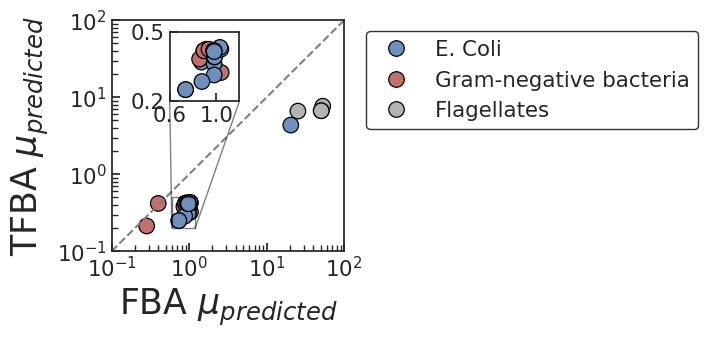

In [ ]:
from matplotlib.ticker import ScalarFormatter
s_tfba=s_tfba[['stoichiometric optimization','T-S optimization','group']]
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.scatterplot(s_tfba,x='stoichiometric optimization',y='T-S optimization',hue='group',**cfg['settings_scatterplots'],ax=ax)
ax.legend(edgecolor='black',loc='upper left',bbox_to_anchor=(1.05, 1))
ax.plot([0,1],[0,1],transform=ax.transAxes,**cfg['settings_diagonal'])
ax.set_xlim(1e-1,1e2)
ax.set_ylim(1e-1,1e2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('FBA $\mu_{predicted}$')
ax.set_ylabel('TFBA $\mu_{predicted}$')

## add inset axes 
axins=ax.inset_axes([0.25,0.65,0.3,0.3])
sns.scatterplot(s_tfba,x='stoichiometric optimization',y='T-S optimization',hue='group',**cfg['settings_scatterplots'],ax=axins,legend=False)
axins.set_xlim(6e-1,1.2)
axins.set_ylim(2e-1,0.5)
axins.set_xticks([0.6,1])
# axins.get_xaxis().set_major_formatter(ScalarFormatter())
axins.set_yticks([0.2,0.5])
axins.set_xlabel('')
axins.set_ylabel('')
ax.indicate_inset_zoom(axins,edgecolor='black')

# plt.savefig('Figures/fixeddir_FBA_vs_TFBA.png',dpi=300,bbox_inches='tight')
# plt.savefig('Figures/fixeddir_FBA_vs_TFBA.svg',dpi=300,bbox_inches='tight')

## we plot groups of organisms

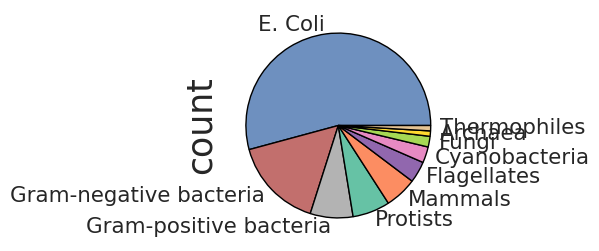

In [15]:
#pie plot
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
org['group'].value_counts().plot.pie(colors=palette,ax=ax,wedgeprops={"edgecolor":'black'})
# plt.savefig('Figures/groups_pieplot.png',dpi=300,bbox_inches='tight')
# plt.savefig('Figures/groups_pieplot.svg',dpi=300,bbox_inches='tight')